In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="qrdj3IOYsQPnAjbelToq")
project = rf.workspace("computer-vision-zycc2").project("drywall-join-detect-rkqd2")
version = project.version(1)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 74.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drywall-Join-Detect-1 in coco:: 100%|██████████| 1030/1030 [00:00<00:00, 8492.76it/s]


In [3]:
import json

for split in ["/content/Drywall-Join-Detect-1/train", "/content/Drywall-Join-Detect-1/valid", "/content/Drywall-Join-Detect-1/test"]:
    with open(f"{split}/_annotations.coco.json") as f:
        data = json.load(f)

    print(f"\n── {split.upper()} ──")
    print(f"  Images      : {len(data['images'])}")
    print(f"  Annotations : {len(data['annotations'])}")
    print(f"  Categories  : {[c['name'] for c in data['categories']]}")

    # Show a sample annotation
    ann = data['annotations'][0]
    print(f"  Sample bbox : {ann['bbox']}")
    print(f"  Sample keys : {list(ann.keys())}")


── /CONTENT/DRYWALL-JOIN-DETECT-1/TRAIN ──
  Images      : 818
  Annotations : 1154
  Categories  : ['Drywall-Join', 'drywall-join']
  Sample bbox : [0, 229, 564, 182]
  Sample keys : ['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd']

── /CONTENT/DRYWALL-JOIN-DETECT-1/VALID ──
  Images      : 102
  Annotations : 133
  Categories  : ['Drywall-Join', 'drywall-join']
  Sample bbox : [319, 25, 26, 545]
  Sample keys : ['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd']

── /CONTENT/DRYWALL-JOIN-DETECT-1/TEST ──
  Images      : 102
  Annotations : 137
  Categories  : ['Drywall-Join', 'drywall-join']
  Sample bbox : [267, 330, 192, 310]
  Sample keys : ['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd']


In [5]:
import json
import os

# ── Config ──────────────────────────────────────────────────
BASE_DIR   = "/content/Drywall-Join-Detect-1"
SPLITS     = ["train", "valid", "test"]
ANN_FILE   = "_annotations.coco.json"

# All variants (any case) → single clean prompt
CATEGORY_PROMPT = "drywall joint"   # what we'll feed Grounding DINO
# ────────────────────────────────────────────────────────────

def fix_and_preprocess(ann_path, out_path):
    with open(ann_path) as f:
        data = json.load(f)

    print(f"\n── Processing: {ann_path}")
    print(f"   Original categories: {[c['name'] for c in data['categories']]}")

    # ── Step 1: Merge all categories into one ──
    # Keep only one canonical category
    canonical_cat = {"id": 1, "name": "drywall joint", "supercategory": "none"}
    data["categories"] = [canonical_cat]

    # Build a remapping: any old category_id → 1
    # (works whether there were 2 or 10 duplicate variants)
    old_cat_ids = set(ann["category_id"] for ann in data["annotations"])
    print(f"   Old category IDs found in annotations: {old_cat_ids}")
    cat_remap = {old_id: 1 for old_id in old_cat_ids}

    # ── Step 2: Remap all annotation category_ids ──
    for ann in data["annotations"]:
        ann["category_id"] = cat_remap[ann["category_id"]]
        ann["phrase"]      = CATEGORY_PROMPT   # for Grounding DINO

    # ── Step 3: Add caption to each image ──
    # (all images get same caption since we only have one class)
    for img in data["images"]:
        img["caption"] = CATEGORY_PROMPT

    # ── Step 4: Verify fix ──
    unique_cats = set(ann["category_id"] for ann in data["annotations"])
    print(f"   Fixed category IDs  : {unique_cats}")
    print(f"   Sample caption      : {data['images'][0]['caption']}")
    print(f"   Sample phrase       : {data['annotations'][0]['phrase']}")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"   ✅ Saved → {out_path}")


# Run for all splits
for split in SPLITS:
    ann_path = os.path.join(BASE_DIR, split, ANN_FILE)
    out_path = os.path.join(BASE_DIR, split, "_annotations_gdino.json")
    fix_and_preprocess(ann_path, out_path)

print("\n🎉 All splits fixed and preprocessed!")


── Processing: /content/Drywall-Join-Detect-1/train/_annotations.coco.json
   Original categories: ['Drywall-Join', 'drywall-join']
   Old category IDs found in annotations: {1}
   Fixed category IDs  : {1}
   Sample caption      : drywall joint
   Sample phrase       : drywall joint
   ✅ Saved → /content/Drywall-Join-Detect-1/train/_annotations_gdino.json

── Processing: /content/Drywall-Join-Detect-1/valid/_annotations.coco.json
   Original categories: ['Drywall-Join', 'drywall-join']
   Old category IDs found in annotations: {1}
   Fixed category IDs  : {1}
   Sample caption      : drywall joint
   Sample phrase       : drywall joint
   ✅ Saved → /content/Drywall-Join-Detect-1/valid/_annotations_gdino.json

── Processing: /content/Drywall-Join-Detect-1/test/_annotations.coco.json
   Original categories: ['Drywall-Join', 'drywall-join']
   Old category IDs found in annotations: {1}
   Fixed category IDs  : {1}
   Sample caption      : drywall joint
   Sample phrase       : drywall j

### loading grounding DINO base

In [8]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

MODEL_ID  = "IDEA-Research/grounding-dino-base"
DEVICE    = "cuda"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID)
model.to(DEVICE)

# Check VRAM usage after loading
allocated = torch.cuda.memory_allocated() / 1e9
reserved  = torch.cuda.memory_reserved()  / 1e9
print(f"✅ Model loaded successfully")
print(f"   VRAM allocated : {allocated:.2f} GB")
print(f"   VRAM reserved  : {reserved:.2f} GB")
print(f"   VRAM remaining : {15.6 - reserved:.2f} GB")


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

✅ Model loaded successfully
   VRAM allocated : 0.94 GB
   VRAM reserved  : 0.95 GB
   VRAM remaining : 14.65 GB


In [9]:
import json
from PIL import Image
import os

BASE_DIR = "/content/Drywall-Join-Detect-1"

for split in ["train", "valid", "test"]:
    ann_path = f"{BASE_DIR}/{split}/_annotations_gdino.json"
    img_dir  = f"{BASE_DIR}/{split}"

    with open(ann_path) as f:
        data = json.load(f)

    # Try loading first 5 images
    errors = []
    for img_meta in data["images"][:5]:
        img_path = os.path.join(img_dir, img_meta["file_name"])
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            errors.append((img_meta["file_name"], str(e)))

    status = "✅" if not errors else f"❌ {len(errors)} errors"
    print(f"{split:6s} | {status} | sample size: {img.size}")

    if errors:
        for fname, err in errors:
            print(f"  ERROR: {fname} → {err}")

train  | ✅ | sample size: (640, 640)
valid  | ✅ | sample size: (640, 640)
test   | ✅ | sample size: (640, 640)


In [6]:
!pip install transformers accelerate pycocotools pillow opencv-python torch torchvision

In [7]:
import torch
print(torch.cuda.is_available())          # should be True
print(torch.cuda.get_device_name(0))      # should say Tesla T4
print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")  # should be ~15.9

True
Tesla T4
15.637086208 GB


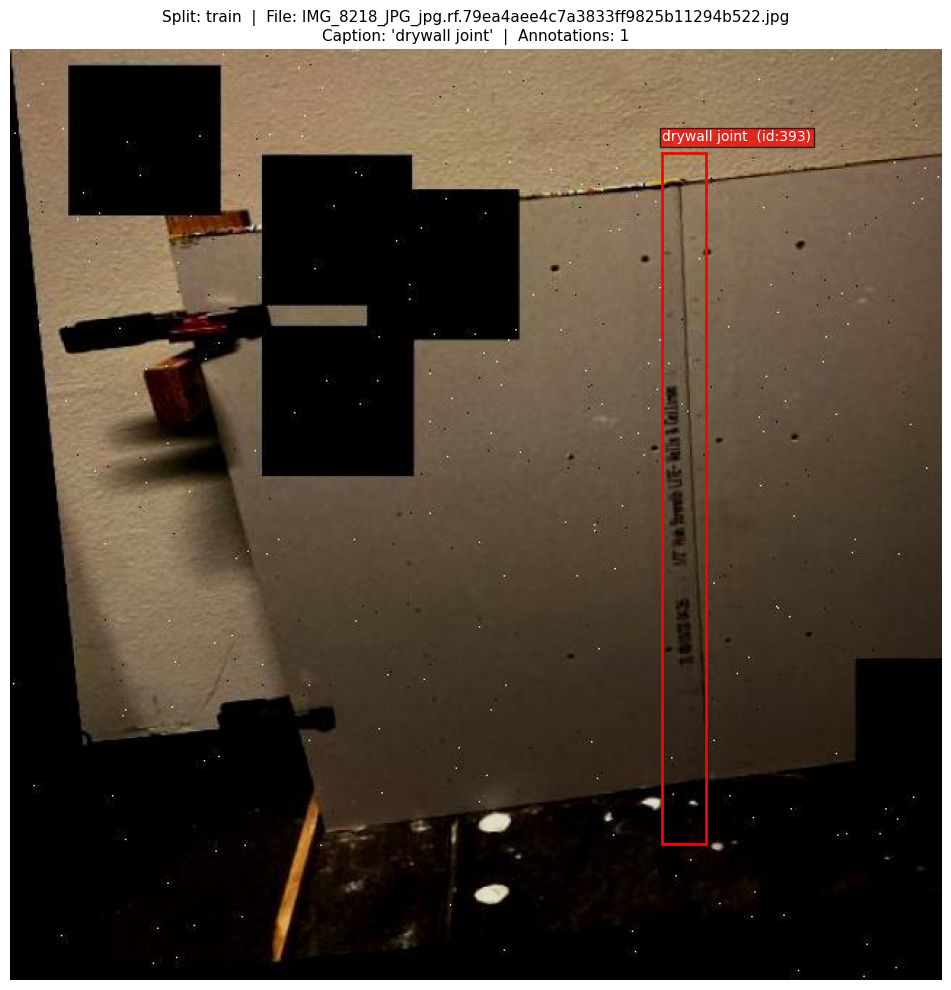

── Sample Details ─────────────────────────────
  Image file  : IMG_8218_JPG_jpg.rf.79ea4aee4c7a3833ff9825b11294b522.jpg
  Image size  : 640 x 640
  Caption     : drywall joint
  Annotations : 1
  [1] phrase: 'drywall joint'  bbox: x=448 y=71 w=30 h=475  area: 14250
───────────────────────────────────────────────


In [16]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import random

BASE_DIR = "/content/Drywall-Join-Detect-1"

def visualize_sample(split="train", idx=None):
    ann_path = f"{BASE_DIR}/{split}/_annotations_gdino.json"
    img_dir  = f"{BASE_DIR}/{split}"

    with open(ann_path) as f:
        data = json.load(f)

    # Build lookup
    img_map     = {i["id"]: i for i in data["images"]}
    ann_by_img  = {}
    for ann in data["annotations"]:
        ann_by_img.setdefault(ann["image_id"], []).append(ann)

    img_ids = list(ann_by_img.keys())

    # Pick random or specific index
    img_id   = img_ids[idx if idx is not None else random.randint(0, len(img_ids)-1)]
    img_meta = img_map[img_id]
    anns     = ann_by_img[img_id]

    image    = Image.open(os.path.join(img_dir, img_meta["file_name"])).convert("RGB")
    W, H     = image.size

    # ── Plot ──────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)

    for ann in anns:
        x, y, w, h = ann["bbox"]   # COCO format [x, y, w, h]

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        # Label
        ax.text(
            x, max(0, y - 8),
            f"{ann['phrase']}  (id:{ann['id']})",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.7, pad=2)
        )

    ax.set_title(
        f"Split: {split}  |  File: {img_meta['file_name']}\n"
        f"Caption: '{img_meta['caption']}'  |  Annotations: {len(anns)}",
        fontsize=11
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("/content/sample_visualization.jpg", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Print annotation details ──────────────────────
    print(f"── Sample Details ─────────────────────────────")
    print(f"  Image file  : {img_meta['file_name']}")
    print(f"  Image size  : {W} x {H}")
    print(f"  Caption     : {img_meta['caption']}")
    print(f"  Annotations : {len(anns)}")
    for i, ann in enumerate(anns):
        x, y, w, h = ann["bbox"]
        print(f"  [{i+1}] phrase: '{ann['phrase']}'  "
              f"bbox: x={x:.0f} y={y:.0f} w={w:.0f} h={h:.0f}  "
              f"area: {ann['area']:.0f}")
    print(f"───────────────────────────────────────────────")


visualize_sample(split="train", idx=None)

### freezed the visual backbone and text backbone

In [14]:
from transformers import AutoModelForZeroShotObjectDetection
import torch

model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base")
model.to("cuda")

# ── Freeze visual backbone ──────────────────────────
for param in model.model.backbone.parameters():
    param.requires_grad = False

# ── Freeze text backbone (BERT) ─────────────────────
for param in model.model.text_backbone.parameters():
    param.requires_grad = False

# ── Verify ──────────────────────────────────────────
total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen     = total - trainable

print(f"── Freezing Summary ───────────────────────────────")
print(f"  Total params     : {total:>12,}")
print(f"  Frozen params    : {frozen:>12,}  ({100*frozen/total:.1f}%)")
print(f"  Trainable params : {trainable:>12,}  ({100*trainable/total:.1f}%)")
print(f"───────────────────────────────────────────────────")



Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

── Freezing Summary ───────────────────────────────
  Total params     :  232,313,216
  Frozen params    :  195,771,768  (84.3%)
  Trainable params :   36,541,448  (15.7%)
───────────────────────────────────────────────────

── Per Component ───────────────────────────────────
  backbone                                 🔒 FROZEN  trainable:          0
  input_proj_vision                        🔥 TRAINING  trainable:  2,821,120
  text_backbone                            🔒 FROZEN  trainable:          0
  text_projection                          🔥 TRAINING  trainable:    196,864
  query_position_embeddings                🔥 TRAINING  trainable:    230,400
  encoder                                  🔥 TRAINING  trainable: 21,905,664
  decoder                                  🔥 TRAINING  trainable: 11,187,460
  enc_output                               🔥 TRAINING  trainable:     65,792
  enc_output_norm                          🔥 TRAINING  trainable:        512
  encoder_output_bbox_embed      

In [25]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
import json
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor
from PIL import Image
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────
BASE_DIR  = "/content/Drywall-Join-Detect-1"
TRAIN_ANN = f"{BASE_DIR}/train/_annotations_gdino.json"
TRAIN_IMG = f"{BASE_DIR}/train"
VAL_ANN   = f"{BASE_DIR}/valid/_annotations_gdino.json"
VAL_IMG   = f"{BASE_DIR}/valid"

MODEL_ID    = "IDEA-Research/grounding-dino-base"
SAVE_DIR    = "/content/gdino-drywall-best"
DEVICE      = "cuda"
BATCH_SIZE  = 1
EPOCHS      = 20
LR          = 1e-5
ACCUM_STEPS = 4
# ────────────────────────────────────────────────────


# ── Dataset ──────────────────────────────────────────
class DrywallDataset(Dataset):
    def __init__(self, ann_file, img_dir):
        self.img_dir = img_dir
        with open(ann_file) as f:
            data = json.load(f)
        self.images = {i["id"]: i for i in data["images"]}
        self.ann_by_img = {}
        for ann in data["annotations"]:
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)
        self.img_ids = list(self.ann_by_img.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_meta = self.images[img_id]
        anns     = self.ann_by_img[img_id]
        image    = Image.open(
            os.path.join(self.img_dir, img_meta["file_name"])
        ).convert("RGB")
        W, H    = image.size
        caption = img_meta["caption"]
        boxes = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([
                max(0.0, x / W),
                max(0.0, y / H),
                min(1.0, (x + w) / W),
                min(1.0, (y + h) / H),
            ])
        return image, caption, torch.tensor(boxes, dtype=torch.float32)


def collate_fn(batch):
    return batch


# ── Loss Function ─────────────────────────────────────
def compute_loss(outputs, gt_boxes, processor, input_ids, image_size):
    """
    Uses the raw logits directly from outputs (no detach)
    so gradient chain stays intact for backprop.
    """
    H, W = image_size

    # ── Get raw logits directly — no post_process ──
    # outputs.logits shape: (1, num_queries, num_text_tokens)
    # outputs.pred_boxes shape: (1, num_queries, 4) — cx,cy,w,h normalised
    pred_logits = outputs.logits[0]        # (num_queries, num_tokens)
    pred_boxes  = outputs.pred_boxes[0]    # (num_queries, 4) cx cy w h

    # Convert cx,cy,w,h → x1,y1,x2,y2
    cx, cy, w, h = pred_boxes.unbind(-1)
    pred_xyxy = torch.stack([
        cx - w / 2,
        cy - h / 2,
        cx + w / 2,
        cy + h / 2,
    ], dim=-1).clamp(0, 1)               # (num_queries, 4) normalised

    gt_boxes = gt_boxes.to(DEVICE)        # (M, 4) normalised x1y1x2y2

    # ── Match predictions to GT via IoU ──────────────
    with torch.no_grad():
        # IoU between all predictions and GT boxes
        area_p = (pred_xyxy[:, 2] - pred_xyxy[:, 0]) * \
                 (pred_xyxy[:, 3] - pred_xyxy[:, 1])
        area_g = (gt_boxes[:, 2] - gt_boxes[:, 0]) * \
                 (gt_boxes[:, 3] - gt_boxes[:, 1])

        ix1 = torch.max(pred_xyxy[:, 0].unsqueeze(1), gt_boxes[:, 0].unsqueeze(0))
        iy1 = torch.max(pred_xyxy[:, 1].unsqueeze(1), gt_boxes[:, 1].unsqueeze(0))
        ix2 = torch.min(pred_xyxy[:, 2].unsqueeze(1), gt_boxes[:, 2].unsqueeze(0))
        iy2 = torch.min(pred_xyxy[:, 3].unsqueeze(1), gt_boxes[:, 3].unsqueeze(0))

        inter    = (ix2 - ix1).clamp(0) * (iy2 - iy1).clamp(0)
        union    = area_p.unsqueeze(1) + area_g.unsqueeze(0) - inter
        iou_mat  = inter / union.clamp(1e-6)          # (num_queries, M)

        best_iou, best_gt_idx = iou_mat.max(dim=1)    # (num_queries,)
        labels = (best_iou > 0.5).float()             # 1=pos, 0=neg

    # ── Classification loss ──────────────────────────
    # Score per query = max logit across text tokens
    scores   = pred_logits.max(dim=-1).values          # (num_queries,)
    cls_loss = F.binary_cross_entropy_with_logits(
        scores,
        labels,
        pos_weight=torch.tensor(2.0, device=DEVICE)
    )

    # ── Regression loss on positives ─────────────────
    pos_mask = labels.bool()
    reg_loss = torch.tensor(0.0, device=DEVICE)

    if pos_mask.sum() > 0:
        # Convert GT to cx,cy,w,h for L1 against pred_boxes
        gt_matched  = gt_boxes[best_gt_idx[pos_mask]]  # x1y1x2y2
        gt_cx = (gt_matched[:, 0] + gt_matched[:, 2]) / 2
        gt_cy = (gt_matched[:, 1] + gt_matched[:, 3]) / 2
        gt_w  =  gt_matched[:, 2] - gt_matched[:, 0]
        gt_h  =  gt_matched[:, 3] - gt_matched[:, 1]
        gt_cxcywh = torch.stack([gt_cx, gt_cy, gt_w, gt_h], dim=-1)

        reg_loss = F.l1_loss(pred_boxes[pos_mask], gt_cxcywh)

    return cls_loss + reg_loss


# ── Training ──────────────────────────────────────────
def train():
    gc.collect()
    torch.cuda.empty_cache()

    print("── Loading model ──────────────────────────────")
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID)

    # Freeze backbone + text backbone
    for param in model.model.backbone.parameters():
        param.requires_grad = False
    for param in model.model.text_backbone.parameters():
        param.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Trainable : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    model.to(DEVICE)
    print(f"   VRAM after load : {torch.cuda.memory_allocated()/1e9:.2f} GB")

    print("\n── Loading datasets ────────────────────────────")
    train_ds = DrywallDataset(TRAIN_ANN, TRAIN_IMG)
    val_ds   = DrywallDataset(VAL_ANN,   VAL_IMG)
    print(f"   Train : {len(train_ds)} images")
    print(f"   Val   : {len(val_ds)} images")

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True,  collate_fn=collate_fn,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE,
        shuffle=False, collate_fn=collate_fn,
        num_workers=2, pin_memory=True
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )
    scaler = torch.cuda.amp.GradScaler()

    best_val_loss = float("inf")
    history       = {"train": [], "val": []}

    print(f"\n── Training ────────────────────────────────────")
    print(f"   Batch size  : {BATCH_SIZE}")
    print(f"   Accum steps : {ACCUM_STEPS} (effective batch = {BATCH_SIZE * ACCUM_STEPS})")
    print(f"   Epochs      : {EPOCHS} | LR : {LR}")
    print(f"────────────────────────────────────────────────\n")

    for epoch in range(EPOCHS):

        # ════════ TRAIN ══════════════════════════════
        model.train()
        train_loss, train_steps = 0.0, 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            for image, caption, boxes in batch:
                inputs = processor(
                    images=image,
                    text=caption,
                    return_tensors="pt"
                ).to(DEVICE)

                with torch.cuda.amp.autocast():
                    outputs = model(**inputs)

                W, H = image.size
                loss  = compute_loss(
                    outputs, boxes,
                    processor, inputs.input_ids,
                    (H, W)
                )

                # Check loss has grad before backward
                if not loss.requires_grad:
                    loss = loss.requires_grad_(True)

                scaled = loss / ACCUM_STEPS
                scaler.scale(scaled).backward()
                train_loss  += loss.item()
                train_steps += 1

            # Optimizer step every ACCUM_STEPS
            if (step + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                torch.cuda.empty_cache()

        # Final optimizer step for remaining batches
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        # ════════ VALIDATE ═══════════════════════════
        model.eval()
        val_loss, val_steps = 0.0, 0

        with torch.no_grad():
            for batch in val_loader:
                for image, caption, boxes in batch:
                    inputs = processor(
                        images=image,
                        text=caption,
                        return_tensors="pt"
                    ).to(DEVICE)

                    with torch.cuda.amp.autocast():
                        outputs = model(**inputs)

                    W, H = image.size
                    loss  = compute_loss(
                        outputs, boxes,
                        processor, inputs.input_ids,
                        (H, W)
                    )
                    val_loss  += loss.item()
                    val_steps += 1

        torch.cuda.empty_cache()

        avg_train = train_loss / train_steps
        avg_val   = val_loss   / val_steps
        scheduler.step()

        history["train"].append(avg_train)
        history["val"].append(avg_val)

        is_best = avg_val < best_val_loss
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | "
              f"Val: {avg_val:.4f}"
              + (" ← ✅ best" if is_best else ""))

        if is_best:
            best_val_loss = avg_val
            os.makedirs(SAVE_DIR, exist_ok=True)
            model.save_pretrained(SAVE_DIR)
            processor.save_pretrained(SAVE_DIR)

    print(f"\n🎉 Training complete!")
    print(f"   Best val loss : {best_val_loss:.4f}")
    print(f"   Saved to      : {SAVE_DIR}")
    return history


history = train()

── Loading model ──────────────────────────────


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

   Trainable : 36,541,448 / 232,313,216 (15.7%)
   VRAM after load : 6.60 GB

── Loading datasets ────────────────────────────
   Train : 818 images
   Val   : 102 images

── Training ────────────────────────────────────
   Batch size  : 1
   Accum steps : 4 (effective batch = 4)
   Epochs      : 20 | LR : 1e-05
────────────────────────────────────────────────

Epoch 01/20 | Train: 0.2291 | Val: 0.2409 ← ✅ best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 02/20 | Train: 0.2082 | Val: 0.1945 ← ✅ best


...

Epoch 14/20 | Train: 0.1817 | Val: 0.1722 ← ✅ best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 15/20 | Train: 0.1822 | Val: 0.1653 ← ✅ best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [31]:
import torch
import json
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────
BASE_DIR   = "/content/Drywall-Join-Detect-1"
TEST_ANN   = f"{BASE_DIR}/test/_annotations_gdino.json"
TEST_IMG   = f"{BASE_DIR}/test"
MODEL_PATH = "/content/gdino-drywall-best"
SAVE_DIR   = "/content/drive/MyDrive/drywall_join"
DEVICE     = "cuda"

PROMPT_1   = "drywall joint"
PROMPT_2   = "drywall seam"
MAX_VIZ    = 4
# ────────────────────────────────────────────────────

os.makedirs(SAVE_DIR, exist_ok=True)


# ── IoU ──────────────────────────────────────────────
def compute_iou(pred_boxes, gt_boxes, img_w, img_h):
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0
    ious = []
    for gt in gt_boxes:
        x, y, w, h = gt
        gt_x1, gt_y1, gt_x2, gt_y2 = x, y, x+w, y+h
        best = 0.0
        for pb in pred_boxes:
            px1, py1, px2, py2 = pb
            ix1 = max(gt_x1, px1); iy1 = max(gt_y1, py1)
            ix2 = min(gt_x2, px2); iy2 = min(gt_y2, py2)
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            union = (gt_x2-gt_x1)*(gt_y2-gt_y1) + \
                    (px2-px1)*(py2-py1) - inter
            best  = max(best, inter / (union + 1e-6))
        ious.append(best)
    return float(np.mean(ious))


# ── Dice ─────────────────────────────────────────────
def compute_dice(pred_boxes, gt_boxes, img_w, img_h):
    pred_mask = np.zeros((img_h, img_w), dtype=np.float32)
    gt_mask   = np.zeros((img_h, img_w), dtype=np.float32)
    for pb in pred_boxes:
        x1, y1, x2, y2 = map(int, pb)
        pred_mask[y1:y2, x1:x2] = 1.0
    for gt in gt_boxes:
        x, y, w, h = map(int, gt)
        gt_mask[y:y+h, x:x+w] = 1.0
    inter = (pred_mask * gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    return float(2 * inter / (total + 1e-6))


# ── Inference — max confidence box only ──────────────
def run_inference(model, processor, image, prompt):
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(DEVICE)

    start = time.time()
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(**inputs)
    elapsed = time.time() - start

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.05,       # low — let everything through
        text_threshold=0.05,  # filter by taking max score
        target_sizes=[image.size[::-1]]
    )[0]

    boxes  = results["boxes"].cpu().tolist()
    scores = results["scores"].cpu().tolist()

    # Return only highest confidence box
    if len(boxes) == 0:
        return [], [], elapsed

    best_idx = scores.index(max(scores))
    return [boxes[best_idx]], [scores[best_idx]], elapsed


# ── Visualisation ─────────────────────────────────────
def save_visualization(image, gt_anns,
                        boxes_p1, scores_p1,
                        boxes_p2, scores_p2,
                        save_path, img_name):

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    titles = [
        "Original Image",
        "Ground Truth",
        f"Prompt 1: '{PROMPT_1}'",
        f"Prompt 2: '{PROMPT_2}'"
    ]

    for ax, title in zip(axes, titles):
        ax.imshow(image)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")

    # GT boxes — green
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        axes[1].add_patch(patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor="lime", facecolor="none"
        ))
        axes[1].text(x, max(0, y-8), "GT",
                     color="white", fontsize=9,
                     bbox=dict(facecolor="lime", alpha=0.7, pad=1))

    # Prompt 1 boxes — red
    for box, score in zip(boxes_p1, scores_p1):
        x1, y1, x2, y2 = box
        axes[2].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="red", facecolor="none"
        ))
        axes[2].text(x1, max(0, y1-8), f"{score:.2f}",
                     color="white", fontsize=9,
                     bbox=dict(facecolor="red", alpha=0.7, pad=1))

    # Prompt 2 boxes — blue
    for box, score in zip(boxes_p2, scores_p2):
        x1, y1, x2, y2 = box
        axes[3].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="dodgerblue", facecolor="none"
        ))
        axes[3].text(x1, max(0, y1-8), f"{score:.2f}",
                     color="white", fontsize=9,
                     bbox=dict(facecolor="dodgerblue", alpha=0.7, pad=1))

    plt.suptitle(f"File: {img_name}", fontsize=9, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()


# ── Main Evaluation ───────────────────────────────────
def evaluate():
    print("── Loading model ──────────────────────────────")
    processor = AutoProcessor.from_pretrained(MODEL_PATH)
    model     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_PATH)
    model.eval().to(DEVICE)

    print("── Loading test annotations ───────────────────")
    with open(TEST_ANN) as f:
        data = json.load(f)

    img_map    = {i["id"]: i for i in data["images"]}
    ann_by_img = {}
    for ann in data["annotations"]:
        ann_by_img.setdefault(ann["image_id"], []).append(ann)

    img_ids = list(ann_by_img.keys())
    print(f"   Test images : {len(img_ids)}")

    # Accumulators
    iou_p1,  iou_p2  = [], []
    dice_p1, dice_p2 = [], []
    time_p1, time_p2 = [], []
    viz_count = 0

    print("\n── Running evaluation ─────────────────────────")
    for i, img_id in enumerate(img_ids):
        img_meta = img_map[img_id]
        gt_anns  = ann_by_img.get(img_id, [])
        gt_boxes = [a["bbox"] for a in gt_anns]

        image    = Image.open(
            os.path.join(TEST_IMG, img_meta["file_name"])
        ).convert("RGB")
        W, H = image.size

        boxes1, scores1, t1 = run_inference(model, processor, image, PROMPT_1)
        boxes2, scores2, t2 = run_inference(model, processor, image, PROMPT_2)

        iou_p1.append(compute_iou(boxes1, gt_boxes, W, H))
        iou_p2.append(compute_iou(boxes2, gt_boxes, W, H))
        dice_p1.append(compute_dice(boxes1, gt_boxes, W, H))
        dice_p2.append(compute_dice(boxes2, gt_boxes, W, H))
        time_p1.append(t1)
        time_p2.append(t2)

        if viz_count < MAX_VIZ:
            save_path = os.path.join(
                SAVE_DIR, f"viz_{viz_count+1}_{img_meta['file_name']}"
            )
            save_visualization(
                image, gt_anns,
                boxes1, scores1,
                boxes2, scores2,
                save_path, img_meta["file_name"]
            )
            viz_count += 1

        if (i + 1) % 20 == 0:
            print(f"   Processed {i+1}/{len(img_ids)} images...")

    # ── Results ──────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  EVALUATION RESULTS — TEST SET ({len(img_ids)} images)")
    print(f"{'='*55}")
    print(f"  {'Metric':<28} {'Prompt 1':>12} {'Prompt 2':>12}")
    print(f"  {'':─<28} {'':─>12} {'':─>12}")
    print(f"  {'Prompt':<28} {PROMPT_1:>12} {PROMPT_2:>12}")
    print(f"  {'Mean IoU':<28} {np.mean(iou_p1):>12.4f} {np.mean(iou_p2):>12.4f}")
    print(f"  {'Mean Dice':<28} {np.mean(dice_p1):>12.4f} {np.mean(dice_p2):>12.4f}")
    print(f"  {'Avg Inference Time (s)':<28} {np.mean(time_p1):>12.4f} {np.mean(time_p2):>12.4f}")
    print(f"  {'Max IoU':<28} {np.max(iou_p1):>12.4f} {np.max(iou_p2):>12.4f}")
    print(f"  {'Min IoU':<28} {np.min(iou_p1):>12.4f} {np.min(iou_p2):>12.4f}")
    print(f"{'='*55}")
    print(f"\n  Visualizations → {SAVE_DIR}/")

    # Save metrics
    results = {
        "prompt_1": PROMPT_1,
        "prompt_2": PROMPT_2,
        "num_test_images": len(img_ids),
        "prompt_1": {
            "mean_iou":        round(float(np.mean(iou_p1)),  4),
            "mean_dice":       round(float(np.mean(dice_p1)), 4),
            "max_iou":         round(float(np.max(iou_p1)),   4),
            "min_iou":         round(float(np.min(iou_p1)),   4),
            "avg_inference_s": round(float(np.mean(time_p1)), 4),
        },
        "prompt_2": {
            "mean_iou":        round(float(np.mean(iou_p2)),  4),
            "mean_dice":       round(float(np.mean(dice_p2)), 4),
            "max_iou":         round(float(np.max(iou_p2)),   4),
            "min_iou":         round(float(np.min(iou_p2)),   4),
            "avg_inference_s": round(float(np.mean(time_p2)), 4),
        }
    }

    metrics_path = os.path.join(SAVE_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"  Metrics        → {metrics_path}")

    return results


results = evaluate()

── Loading model ──────────────────────────────


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

── Loading test annotations ───────────────────
   Test images : 102

── Running evaluation ─────────────────────────
   Processed 20/102 images...
   Processed 40/102 images...
   Processed 60/102 images...
   Processed 80/102 images...
   Processed 100/102 images...

  EVALUATION RESULTS — TEST SET (102 images)
  Metric                           Prompt 1     Prompt 2
  ──────────────────────────── ──────────── ────────────
  Prompt                       drywall joint drywall seam
  Mean IoU                           0.6798       0.6727
  Mean Dice                          0.7314       0.7194
  Avg Inference Time (s)             0.3031       0.3036
  Max IoU                            0.9444       0.9287
  Min IoU                            0.0000       0.0000

  Visualizations → /content/drive/MyDrive/drywall_join/
  Metrics        → /content/drive/MyDrive/drywall_join/metrics.json


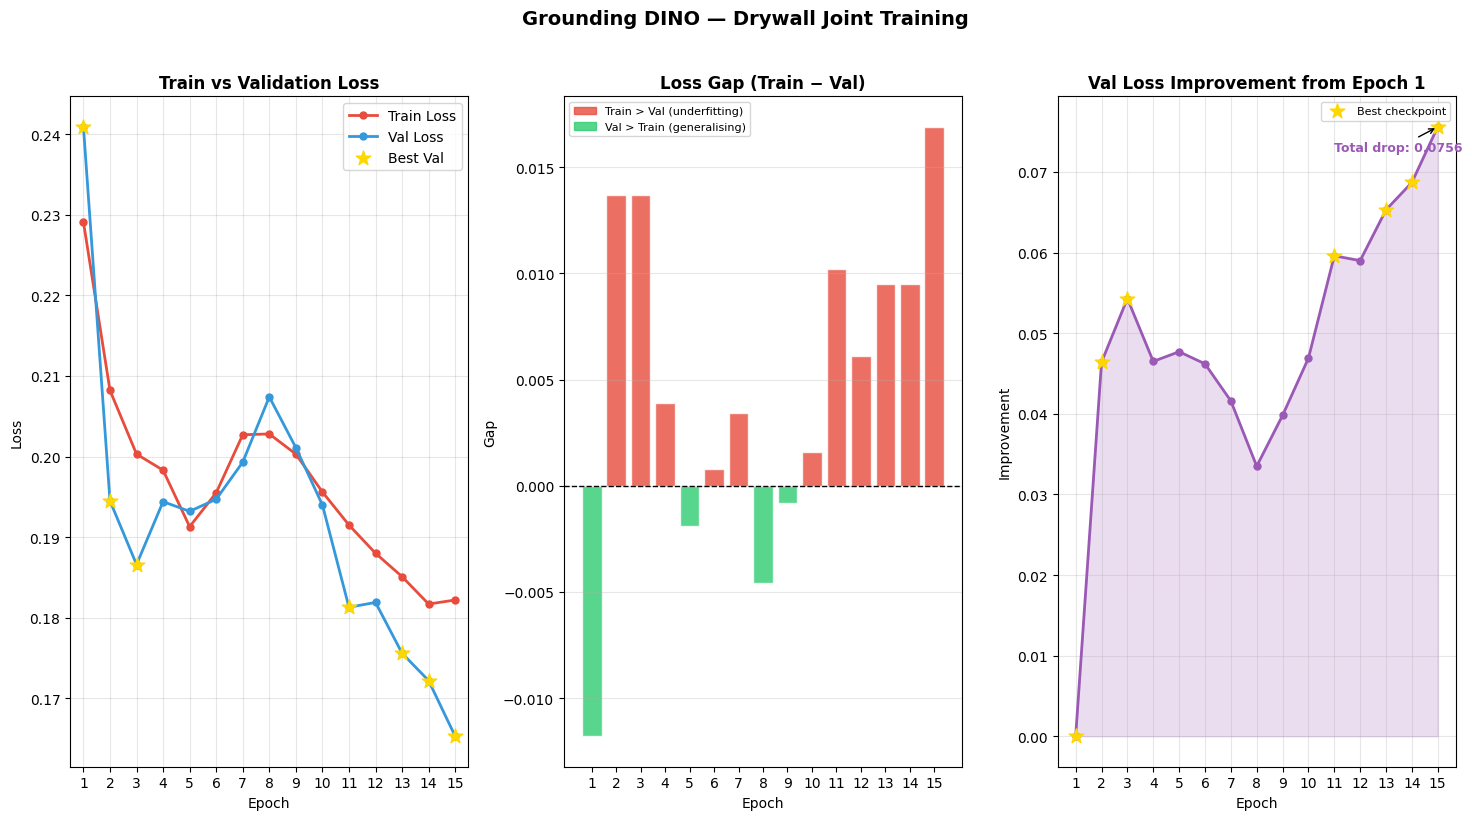

Saved → /content/drive/MyDrive/drywall_join/training_curves.png

── Training Summary ───────────────────────────
  Best val loss    : 0.1653 (Epoch 15)
  Final train loss : 0.1822
  Final val loss   : 0.1653
  Total val drop   : 0.0756
  Epochs to best   : 15
───────────────────────────────────────────────


In [41]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 16))

train_loss = [
    0.2291, 0.2082, 0.2003, 0.1983, 0.1913,
    0.1955, 0.2027, 0.2028, 0.2003, 0.1956,
    0.1915, 0.1880, 0.1851, 0.1817, 0.1822
]

val_loss = [
    0.2409, 0.1945, 0.1866, 0.1944, 0.1932,
    0.1947, 0.1993, 0.2074, 0.2011, 0.1940,
    0.1813, 0.1819, 0.1756, 0.1722, 0.1653
]

best_epochs = [1, 2, 3, 11, 13, 14, 15]
best_val    = [val_loss[e-1] for e in best_epochs]

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
fig.suptitle("Grounding DINO — Drywall Joint Training",
             fontsize=14, fontweight="bold", y=1.02)

# ── Plot 1: Train vs Val Loss ──────────────────────
ax = axes[0]
ax.plot(epochs, train_loss, "o-", color="#E74C3C",
        linewidth=2, markersize=5, label="Train Loss")
ax.plot(epochs, val_loss,   "o-", color="#3498DB",
        linewidth=2, markersize=5, label="Val Loss")
ax.scatter(best_epochs, best_val,
           color="gold", s=120, zorder=5,
           marker="*", label="Best Val")
ax.set_title("Train vs Validation Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(epochs)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 15.5)

# ── Plot 2: Loss Gap (Overfitting Monitor) ─────────
ax = axes[1]
gap = [t - v for t, v in zip(train_loss, val_loss)]
colors = ["#E74C3C" if g > 0 else "#2ECC71" for g in gap]
ax.bar(epochs, gap, color=colors, alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_title("Loss Gap (Train − Val)", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gap")
ax.set_xticks(epochs)
ax.grid(True, alpha=0.3, axis="y")

# Add legend manually
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#E74C3C", alpha=0.8, label="Train > Val (underfitting)"),
    Patch(color="#2ECC71", alpha=0.8, label="Val > Train (generalising)")
], fontsize=8)

# ── Plot 3: Val Loss Improvement ──────────────────
ax = axes[2]
improvement = [val_loss[0] - v for v in val_loss]
ax.fill_between(epochs, improvement, alpha=0.2, color="#9B59B6")
ax.plot(epochs, improvement, "o-", color="#9B59B6",
        linewidth=2, markersize=5)
ax.scatter(best_epochs, [improvement[e-1] for e in best_epochs],
           color="gold", s=120, zorder=5, marker="*", label="Best checkpoint")

# Annotate final improvement
ax.annotate(
    f"Total drop: {improvement[-1]:.4f}",
    xy=(15, improvement[-1]),
    xytext=(11, improvement[-1] - 0.003),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black"),
    color="#9B59B6", fontweight="bold"
)
ax.set_title("Val Loss Improvement from Epoch 1", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Improvement")
ax.set_xticks(epochs)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = "/content/drive/MyDrive/drywall_join/training_curves.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

# ── Summary Stats ─────────────────────────────────
print(f"\n── Training Summary ───────────────────────────")
print(f"  Best val loss    : {min(val_loss):.4f} (Epoch {val_loss.index(min(val_loss))+1})")
print(f"  Final train loss : {train_loss[-1]:.4f}")
print(f"  Final val loss   : {val_loss[-1]:.4f}")
print(f"  Total val drop   : {val_loss[0] - val_loss[-1]:.4f}")
print(f"  Epochs to best   : 15")
print(f"───────────────────────────────────────────────")

In [43]:
import torch
import json
import os
import numpy as np
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image, ImageDraw, ImageFont
import warnings
warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────
BASE_DIR   = "/content/Drywall-Join-Detect-1"
TEST_ANN   = f"{BASE_DIR}/test/_annotations_gdino.json"
TEST_IMG   = f"{BASE_DIR}/test"
MODEL_PATH = "/content/gdino-drywall-best"
SAVE_DIR   = "/content/drive/MyDrive/drywall_join/predictions_drywall"
DEVICE     = "cuda"

PROMPT_1   = "drywall_joint"
PROMPT_2   = "drywall_seam"
PROMPTS    = [PROMPT_1, PROMPT_2]
# ────────────────────────────────────────────────────

os.makedirs(SAVE_DIR, exist_ok=True)


# ── Inference ────────────────────────────────────────
def run_inference(model, processor, image, prompt):
    inputs = processor(
        images=image,
        text=prompt.replace("_", " "),   # "drywall_joint" → "drywall joint"
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.05,
        text_threshold=0.05,
        target_sizes=[image.size[::-1]]
    )[0]

    boxes  = results["boxes"].cpu().tolist()
    scores = results["scores"].cpu().tolist()

    if len(boxes) == 0:
        return [], []

    best_idx = scores.index(max(scores))
    return [boxes[best_idx]], [scores[best_idx]]


# ── Draw + Save ──────────────────────────────────────
def draw_and_save(image, boxes, scores, img_id, prompt):
    """
    Saves prediction image with filename: {img_id}__{prompt}.png
    e.g. 123__drywall_joint.png
    """
    img_copy = image.copy()
    draw     = ImageDraw.Draw(img_copy)

    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box
        # Box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        # Label
        label = f"{prompt} | {score:.2f}"
        draw.rectangle([x1, y1-18, x1+len(label)*7, y1],
                       fill="red")
        draw.text((x1+2, y1-16), label, fill="white")

    # Filename format: {image_id}__{prompt}.png
    filename  = f"{img_id}__{prompt}.png"
    save_path = os.path.join(SAVE_DIR, filename)
    img_copy.save(save_path)
    return filename


# ── Main ─────────────────────────────────────────────
def save_all_predictions():
    print("── Loading model ──────────────────────────────")
    processor = AutoProcessor.from_pretrained(MODEL_PATH)
    model     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_PATH)
    model.eval().to(DEVICE)

    with open(TEST_ANN) as f:
        data = json.load(f)

    img_map    = {i["id"]: i for i in data["images"]}
    ann_by_img = {}
    for ann in data["annotations"]:
        ann_by_img.setdefault(ann["image_id"], []).append(ann)

    img_ids = list(ann_by_img.keys())
    print(f"   Images  : {len(img_ids)}")
    print(f"   Prompts : {PROMPTS}")
    print(f"   Total   : {len(img_ids) * len(PROMPTS)} files to save")
    print(f"   Format  : {{image_id}}__{{prompt}}.png\n")

    saved = []

    for i, img_id in enumerate(img_ids):
        img_meta = img_map[img_id]
        image    = Image.open(
            os.path.join(TEST_IMG, img_meta["file_name"])
        ).convert("RGB")

        for prompt in PROMPTS:
            boxes, scores = run_inference(model, processor, image, prompt)
            filename      = draw_and_save(image, boxes, scores, img_id, prompt)
            saved.append({
                "image_id": img_id,
                "prompt":   prompt,
                "filename": filename,
                "n_boxes":  len(boxes),
                "score":    round(scores[0], 4) if scores else None
            })

        if (i + 1) % 20 == 0:
            print(f"   Processed {i+1}/{len(img_ids)} images...")

    # Save manifest
    manifest_path = os.path.join(SAVE_DIR, "manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(saved, f, indent=2)

    # Summary
    detected_p1 = sum(1 for s in saved if s["prompt"] == PROMPT_1 and s["n_boxes"] > 0)
    detected_p2 = sum(1 for s in saved if s["prompt"] == PROMPT_2 and s["n_boxes"] > 0)

    print(f"\n── Summary ────────────────────────────────────")
    print(f"   Total saved           : {len(saved)} images")
    print(f"   {PROMPT_1} detections : {detected_p1}/{len(img_ids)}")
    print(f"   {PROMPT_2} detections : {detected_p2}/{len(img_ids)}")
    print(f"   Saved to              : {SAVE_DIR}/")
    print(f"   Manifest              : {manifest_path}")
    print(f"   Example filename      : {saved[0]['filename']}")


save_all_predictions()


── Loading model ──────────────────────────────


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

   Images  : 102
   Prompts : ['drywall_joint', 'drywall_seam']
   Total   : 204 files to save
   Format  : {image_id}__{prompt}.png

   Processed 20/102 images...
   Processed 40/102 images...
   Processed 60/102 images...
   Processed 80/102 images...
   Processed 100/102 images...

── Summary ────────────────────────────────────
   Total saved           : 204 images
   drywall_joint detections : 102/102
   drywall_seam detections : 102/102
   Saved to              : /content/drive/MyDrive/drywall_join/predictions_drywall/
   Manifest              : /content/drive/MyDrive/drywall_join/predictions_drywall/manifest.json
   Example filename      : 0__drywall_joint.png


Saved → /content/drive/MyDrive/drywall_join/random_samples.jpg


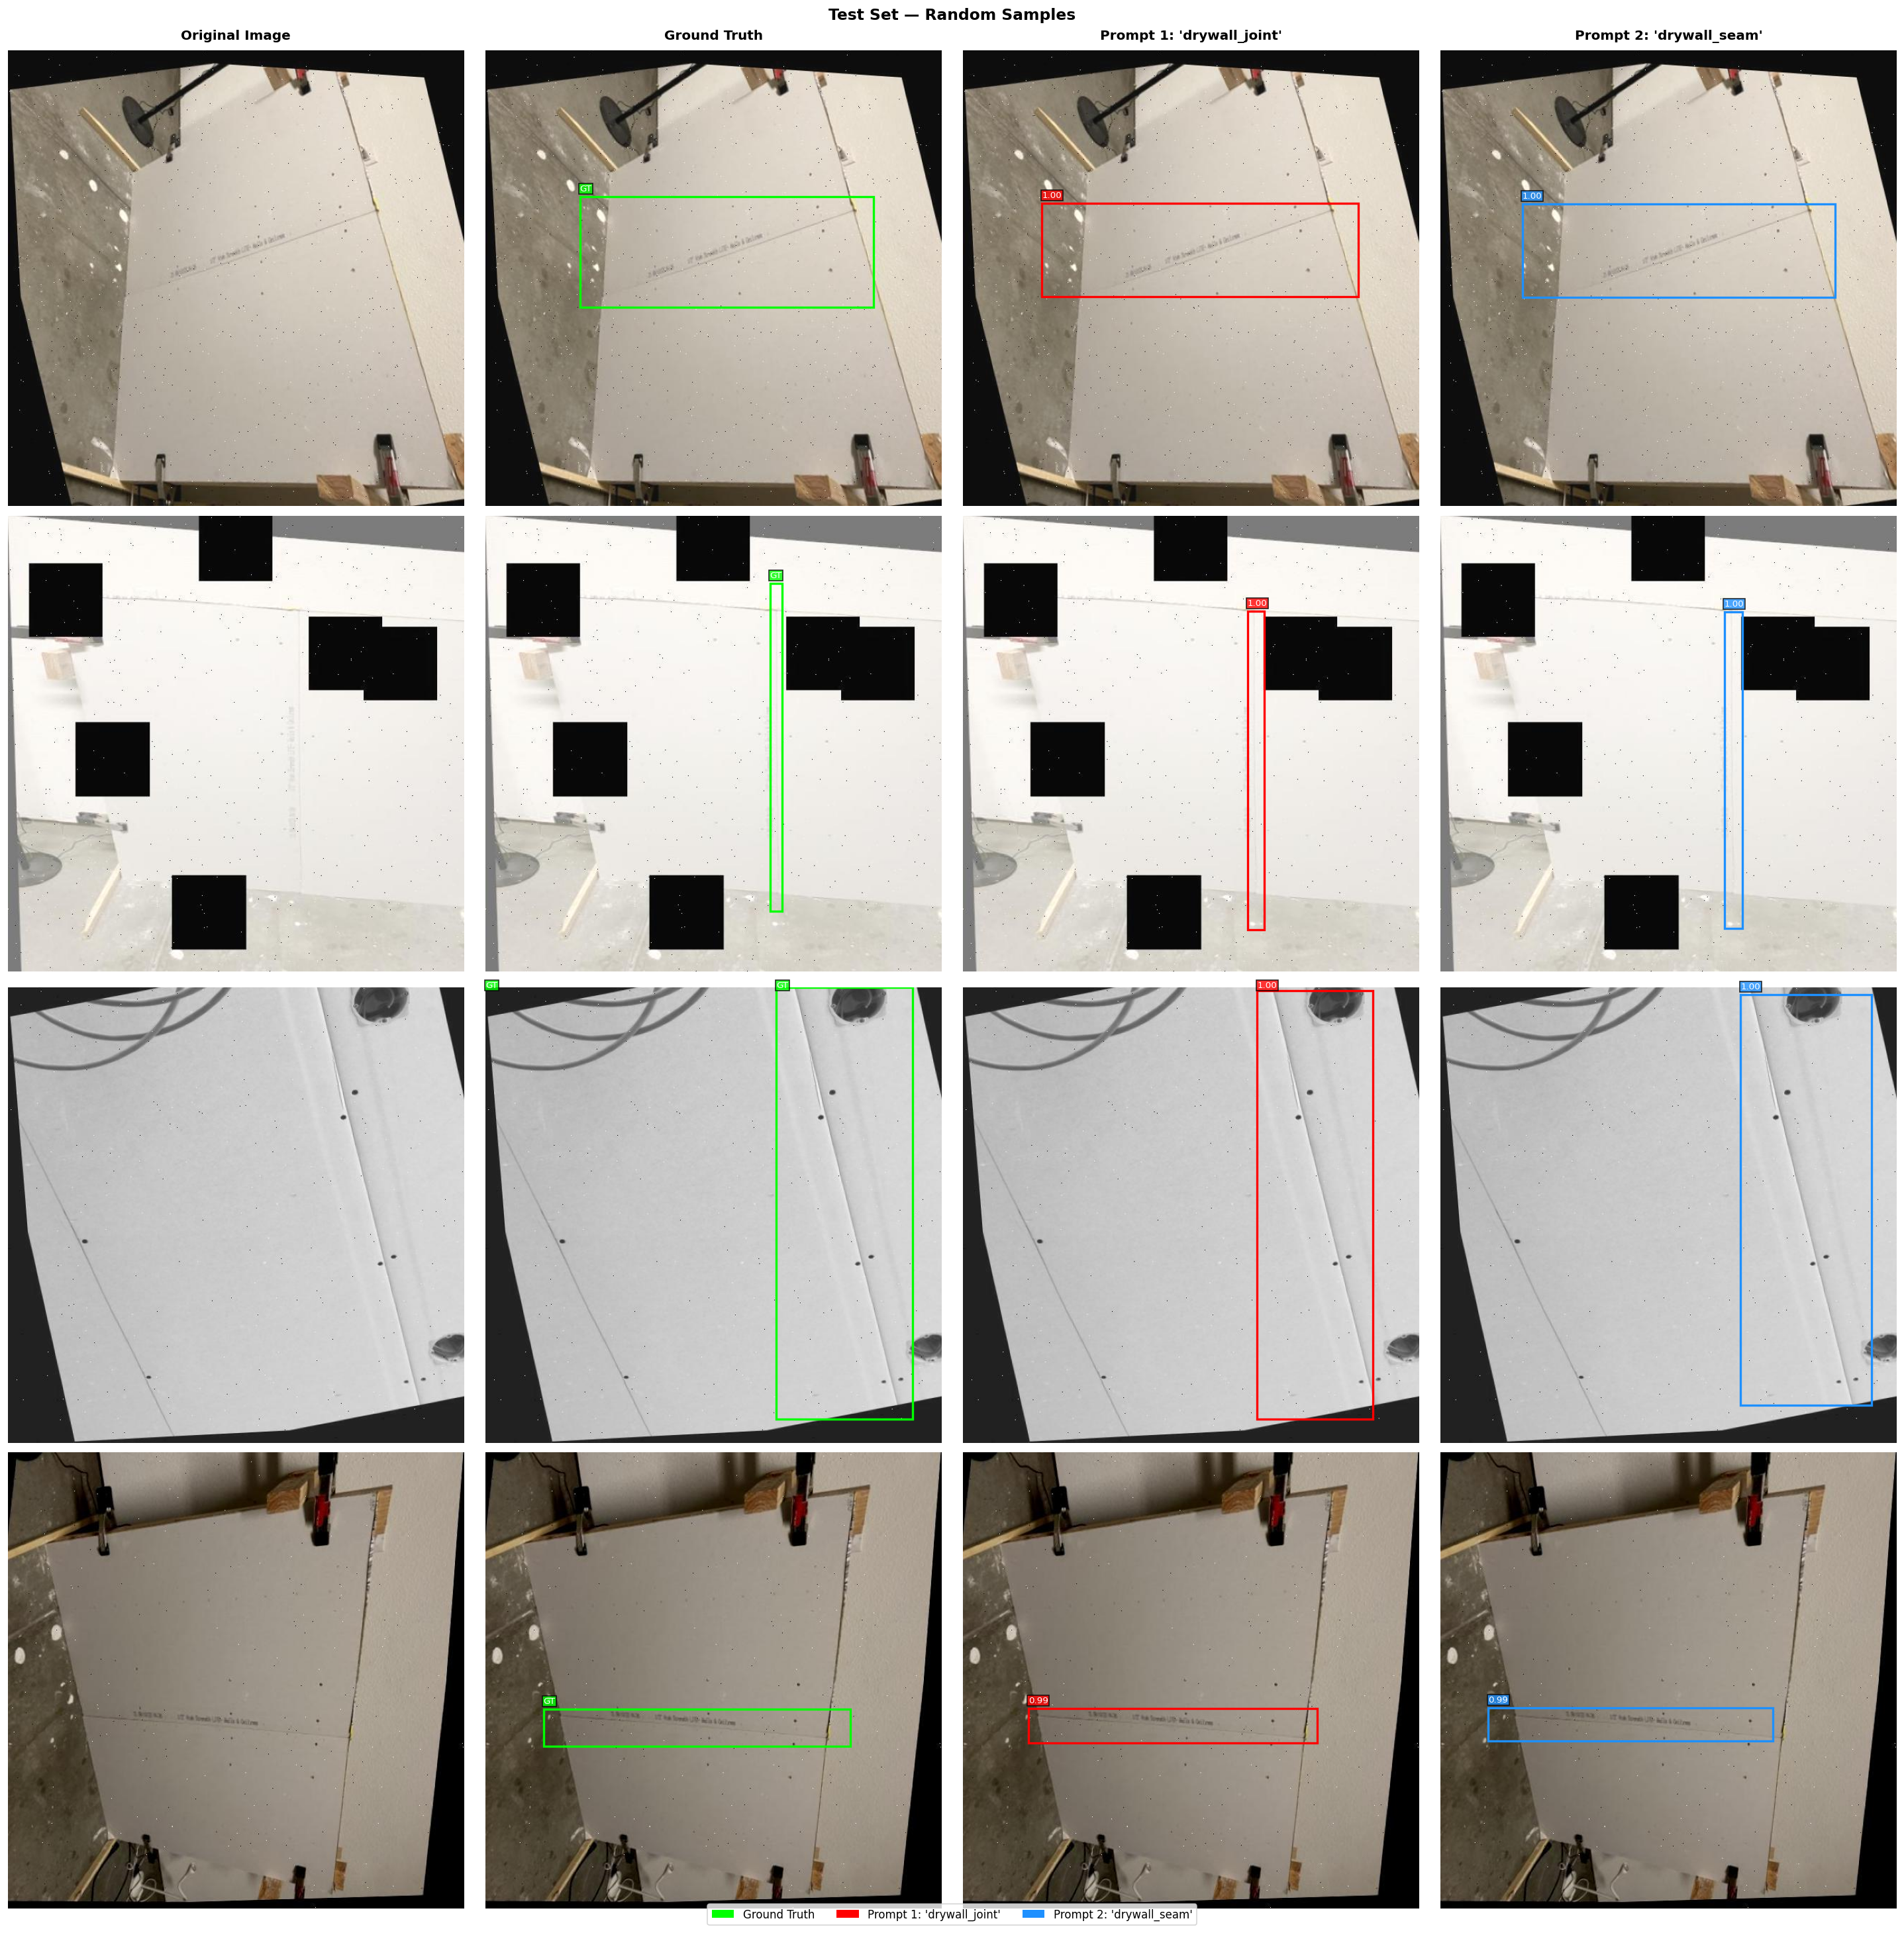

In [50]:
import random
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

# ── Config ───────────────────────────────────────────
BASE_DIR  = "/content/Drywall-Join-Detect-1"
TEST_ANN  = f"{BASE_DIR}/test/_annotations_gdino.json"
TEST_IMG  = f"{BASE_DIR}/test"
SAVE_DIR  = "/content/drive/MyDrive/drywall_join"
PROMPT_1  = "drywall_joint"
PROMPT_2  = "drywall_seam"
# ─────────────────────────────────────────────────────

def visualize_random_samples(n=4):
    with open(TEST_ANN) as f:
        data = json.load(f)

    img_map    = {i["id"]: i for i in data["images"]}
    ann_by_img = {}
    for ann in data["annotations"]:
        ann_by_img.setdefault(ann["image_id"], []).append(ann)

    # Only sample images that exist on disk
    available = [
        img_id for img_id in ann_by_img
        if os.path.exists(
            os.path.join(TEST_IMG, img_map[img_id]["file_name"])
        )
    ]
    sampled_ids = random.sample(available, min(n, len(available)))

    fig, axes = plt.subplots(
        n, 4,
        figsize=(24, 6 * n),
        constrained_layout=True,
        dpi=120
    )

    # Column headers
    for col, title in enumerate([
        "Original Image",
        "Ground Truth",
        f"Prompt 1: '{PROMPT_1}'",
        f"Prompt 2: '{PROMPT_2}'"
    ]):
        axes[0][col].set_title(
            title, fontsize=12, fontweight="bold", pad=10
        )

    for row, img_id in enumerate(sampled_ids):
        img_meta = img_map[img_id]
        gt_anns  = ann_by_img.get(img_id, [])

        image  = Image.open(
            os.path.join(TEST_IMG, img_meta["file_name"])
        ).convert("RGB")
        W, H   = image.size

        # Run inference
        boxes1, scores1 = run_inference(image, PROMPT_1)
        boxes2, scores2 = run_inference(image, PROMPT_2)

        # Base image on all panels
        for col in range(4):
            axes[row][col].imshow(image)
            axes[row][col].axis("off")

        # Row filename
        axes[row][0].set_ylabel(
            img_meta["file_name"][:35],
            fontsize=7, rotation=90, labelpad=6
        )

        # ── Col 0: Original ───────────────────────────
        # clean image, nothing added

        # ── Col 1: Ground Truth ───────────────────────
        if len(gt_anns) == 0:
            axes[row][1].text(
                W//2, H//2, "No GT",
                color="lime", fontsize=11, ha="center",
                bbox=dict(facecolor="black", alpha=0.6, pad=4)
            )
        for ann in gt_anns:
            x, y, w, h = ann["bbox"]
            axes[row][1].add_patch(patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))
            axes[row][1].text(
                x, max(0, y-8), "GT",
                color="white", fontsize=8,
                bbox=dict(facecolor="lime", alpha=0.8, pad=1)
            )

        # ── Col 2: Prompt 1 ───────────────────────────
        if len(boxes1) == 0:
            axes[row][2].text(
                W//2, H//2, "No Detection",
                color="red", fontsize=11, ha="center",
                bbox=dict(facecolor="white", alpha=0.8, pad=4)
            )
        for box, score in zip(boxes1, scores1):
            x1, y1, x2, y2 = box
            axes[row][2].add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            axes[row][2].text(
                x1, max(0, y1-8), f"{score:.2f}",
                color="white", fontsize=8,
                bbox=dict(facecolor="red", alpha=0.8, pad=1)
            )

        # ── Col 3: Prompt 2 ───────────────────────────
        if len(boxes2) == 0:
            axes[row][3].text(
                W//2, H//2, "No Detection",
                color="dodgerblue", fontsize=11, ha="center",
                bbox=dict(facecolor="white", alpha=0.8, pad=4)
            )
        for box, score in zip(boxes2, scores2):
            x1, y1, x2, y2 = box
            axes[row][3].add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="dodgerblue", facecolor="none"
            ))
            axes[row][3].text(
                x1, max(0, y1-8), f"{score:.2f}",
                color="white", fontsize=8,
                bbox=dict(facecolor="dodgerblue", alpha=0.8, pad=1)
            )

    # Legend
    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor="lime",       label="Ground Truth"),
            Patch(facecolor="red",        label=f"Prompt 1: '{PROMPT_1}'"),
            Patch(facecolor="dodgerblue", label=f"Prompt 2: '{PROMPT_2}'"),
        ],
        loc="lower center", ncol=3,
        fontsize=10, frameon=True,
        bbox_to_anchor=(0.5, -0.01)
    )

    fig.suptitle(
        "Test Set — Random Samples",
        fontsize=14, fontweight="bold"
    )

    # Save before show
    save_path = os.path.join(SAVE_DIR, "random_samples.jpg")
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    print(f"Saved → {save_path}")
    plt.show()


visualize_random_samples(n=4)